# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [1]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ["left_right", "right_feet", "left_right_feet_tongue", "5_fingers", "Five Fingers MI", "Left Hand vs Right Hand vs Feet vs Tongue MI", "Left Hand vs Right Hand MI", "Right Hand vs Feet MI"]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "EEGLeJEPABCIModel": "LeJEPA",
    "EEGLeJEPAClinicalModel": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM",
    "REVEModel": "REVE"
}

In [2]:

from collections.abc import Sequence


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def _parse_eval_noise(data: dict) -> dict:
    """Parse evaluation noise metadata with backward compatibility."""
    eval_noise = data.get("eval_noise") or {}
    noise_types = eval_noise.get("noise_types")
    snr_db = eval_noise.get("snr_db")
    tag = eval_noise.get("tag")

    if not noise_types:
        noise_types = data.get("eval_noise_types") or []
    if snr_db is None:
        snr_db = data.get("eval_noise_snr_db")
    if not tag:
        tag = data.get("eval_noise_tag")

    if isinstance(noise_types, str):
        noise_types = [t for t in noise_types.replace(",", "+").split("+") if t]

    if tag is None:
        if snr_db is None or not noise_types:
            tag = "clean"
        else:
            types_str = "+".join(noise_types)
            try:
                snr_val = float(snr_db)
                snr_str = str(int(snr_val)) if snr_val.is_integer() else str(snr_val)
            except Exception:
                snr_str = str(snr_db)
            tag = f"noise_{types_str}_snr{snr_str}dB"

    is_clean = snr_db is None and not noise_types
    return {
        "noise_tag": tag,
        "noise_snr_db": snr_db,
        "noise_types": noise_types,
        "is_clean": is_clean,
    }


def load_results(results_dir="results/raw"):
    """Load all results JSON files into a DataFrame."""
    records = []

    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    for filepath in json_files:
        try:
            with open(filepath) as f:
                data = json.load(f)

            task_name = data.get("task_name", "unknown")
            model_names = data.get("models_names", ["unknown"])
            percentage = data.get("data_percentage", 1.0)
            linear_probe = data.get("linear_probe", False)
            timestamp = data.get("timestamp", "")
            data_stats = data.get("data_stats", {})
            ckpt_id = data.get("checkpoint_id")
            step = None
            if ckpt_id:
                step = int(ckpt_id.split('step_')[-1]) if 'last' not in str(ckpt_id) else ckpt_id

            noise_info = _parse_eval_noise(data)

            y_test = data.get("y_test", [[]])
            results = data.get("results", [[]])

            for i, model_name in enumerate(model_names):
                try:
                    if i < len(results):
                        y_pred = results[i] if isinstance(results[i], list) else results
                        y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                    else:
                        y_pred = results[0] if results else []
                        y_true = y_test[0] if y_test else []

                    metrics = compute_metrics(y_true, y_pred)
                    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                    record = {
                        "task": task_name,
                        "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                        "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                        "model": model_name,
                        "model_display": display_name,
                        "percentage": percentage,
                        "linear_probe": linear_probe,
                        "timestamp": timestamp,
                        "total_samples": data_stats.get("total_samples", 0),
                        "file": os.path.basename(filepath),
                        "step": step,
                        **noise_info,
                        **metrics,
                    }
                    records.append(record)

                except Exception as e:
                    print(f"Warning: Error processing {filepath} model {model_name}: {e}")

        except Exception as e:
            print(f"Warning: Could not load {filepath}: {e}")

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df


In [3]:
# Load results (clean + noise-aware)
df_all = load_results("results/raw")

df_clean = df_all.copy()
df_noise = df_all.iloc[0:0].copy()

if len(df_all) > 0:
    if "noise_types" in df_all.columns:
        df_all["noise_types_str"] = df_all["noise_types"].apply(
            lambda x: "+".join(x) if isinstance(x, (list, tuple)) else ""
        )
    else:
        df_all["noise_types_str"] = ""

    if "is_clean" in df_all.columns:
        df_clean = df_all[df_all["is_clean"]].copy()
        df_noise = df_all[~df_all["is_clean"]].copy()

    # Keep the existing notebook flow on clean-only runs
    df = df_clean.copy()

    print(f"Clean results: {len(df_clean)} rows")
    print(f"Noise results: {len(df_noise)} rows")
    print(f"Unique tasks (clean): {df['task'].nunique()}")
    print(f"Unique models (clean): {df['model_display'].nunique()}")
    print(f"Data percentages (clean): {sorted(df['percentage'].unique())}")
    print(f"Tasks (clean): {df['task'].unique().tolist()}")
    print(f"Models (clean): {df['model_display'].unique().tolist()}")
else:
    df = df_all
    print("No results found. Run experiments first with run_experiments.py")


Found 319 result files
Loaded 317 experiment results
Clean results: 317 rows
Noise results: 0 rows
Unique tasks (clean): 14
Unique models (clean): 3
Data percentages (clean): [0.1, 0.25, 0.5, 0.75, 1.0]
Tasks (clean): ['abnormal_clinical', 'Left Hand vs Right Hand MI', 'multiclass_artifact_clinical', 'Five Fingers MI', 'binary_artifact_clinical', 'sleep_stages_clinical', 'mtbi_clinical', 'schizophrenia_clinical', 'epilepsy_clinical', 'seizure_clinical', 'ocd_clinical', 'Right Hand vs Feet MI', 'parkinsons_clinical', 'Left Hand vs Right Hand vs Feet vs Tongue MI']
Models (clean): ['LaBraM', 'LUNAModel', 'CBraModModel']


In [4]:
# Drop duplicates (excluding run-specific fields), then keep the existing REVE filter
unhashable_cols = {"noise_types"}
exclude_cols = {"timestamp", "file"} | unhashable_cols
subset_cols = [c for c in df.columns if c not in exclude_cols]
df = df.drop_duplicates(subset=subset_cols)

df = df[df['model_display'] != 'REVE']
df


,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,total_samples,file,...,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
0,abnormal_clinical,abnormal_clinical,Clinical,LaBraMModel,LaBraM,0.10,True,20260324_065157,271,abnormal_clinical_LaBraMModel_pct10_LP_2026032...,...,clean,None,[],True,0.695652,0.674921,0.674811,0.666187,0.363217,
1,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,LaBraMModel,LaBraM,1.00,True,20260324_125410,27952,Left Hand vs Right Hand MI_LaBraMModel_LP_2026...,...,clean,None,[],True,0.517729,0.517846,0.517253,0.517306,0.035684,
2,multiclass_artifact_clinical,multiclass_artifact_clinical,Clinical,LUNAModel,LUNAModel,1.00,True,20260324_113253,147572,multiclass_artifact_clinical_LUNAModel_LP_2026...,...,clean,None,[],True,0.483571,0.269733,0.534584,0.260893,0.219739,
3,Five Fingers MI,Five Fingers MI,BCI,LUNAModel,LUNAModel,0.10,True,20260324_062756,1616,Five Fingers MI_LUNAModel_pct10_LP_20260324_06...,...,clean,None,[],True,0.196946,0.193692,0.162001,0.158923,-0.008106,
4,binary_artifact_clinical,binary_artifact_clinical,Clinical,CBraModModel,CBraModModel,0.50,True,20260325_024020,121,binary_artifact_clinical_CBraModModel_pct50_LP...,...,clean,None,[],True,0.657309,0.638724,0.658426,0.637701,0.275536,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,binary_artifact_clinical,binary_artifact_clinical,Clinical,CBraModModel,CBraModModel,0.75,True,20260325_014727,182,binary_artifact_clinical_CBraModModel_pct75_LP...,...,clean,None,[],True,0.722062,0.685282,0.714962,0.690776,0.385116,
313,multiclass_artifact_clinical,multiclass_artifact_clinical,Clinical,CBraModModel,CBraModModel,1.00,True,20260325_071243,147572,multiclass_artifact_clinical_CBraModModel_LP_2...,...,clean,None,[],True,0.410447,0.294171,0.459042,0.218216,0.148879,
314,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,CBraModModel,CBraModModel,1.00,True,20260325_041820,27952,Left Hand vs Right Hand MI_CBraModModel_LP_202...,...,clean,None,[],True,0.498001,0.499863,0.331912,0.333149,-0.000273,
315,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,CBraModModel,CBraModModel,1.00,True,20260325_041705,27952,Left Hand vs Right Hand MI_CBraModModel_LP_202...,...,clean,None,[],True,0.503999,0.504902,0.473193,0.473664,0.009786,


In [5]:
# df.to_csv("results/luna_results.csv")

In [6]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,total_samples,file,...,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
0,abnormal_clinical,abnormal_clinical,Clinical,LaBraMModel,LaBraM,0.10,True,20260324_065157,271,abnormal_clinical_LaBraMModel_pct10_LP_2026032...,...,clean,None,[],True,0.695652,0.674921,0.674811,0.666187,0.363217,
1,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,LaBraMModel,LaBraM,1.00,True,20260324_125410,27952,Left Hand vs Right Hand MI_LaBraMModel_LP_2026...,...,clean,None,[],True,0.517729,0.517846,0.517253,0.517306,0.035684,
2,multiclass_artifact_clinical,multiclass_artifact_clinical,Clinical,LUNAModel,LUNAModel,1.00,True,20260324_113253,147572,multiclass_artifact_clinical_LUNAModel_LP_2026...,...,clean,None,[],True,0.483571,0.269733,0.534584,0.260893,0.219739,
3,Five Fingers MI,Five Fingers MI,BCI,LUNAModel,LUNAModel,0.10,True,20260324_062756,1616,Five Fingers MI_LUNAModel_pct10_LP_20260324_06...,...,clean,None,[],True,0.196946,0.193692,0.162001,0.158923,-0.008106,
4,binary_artifact_clinical,binary_artifact_clinical,Clinical,CBraModModel,CBraModModel,0.50,True,20260325_024020,121,binary_artifact_clinical_CBraModModel_pct50_LP...,...,clean,None,[],True,0.657309,0.638724,0.658426,0.637701,0.275536,
5,sleep_stages_clinical,sleep_stages_clinical,Clinical,CBraModModel,CBraModModel,1.00,True,20260325_062815,4541,sleep_stages_clinical_CBraModModel_LP_20260325...,...,clean,None,[],True,0.297943,0.173227,0.296103,0.170513,0.018432,
6,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,BCI,LaBraMModel,LaBraM,1.00,True,20260324_125258,27952,Left Hand vs Right Hand MI_LaBraMModel_LP_2026...,...,clean,None,[],True,0.508798,0.508987,0.507529,0.507619,0.017968,
7,mtbi_clinical,mtbi_clinical,Clinical,LaBraMModel,LaBraM,1.00,True,20260324_142047,149,mtbi_clinical_LaBraMModel_LP_20260324_142047.json,...,clean,None,[],True,0.607143,0.447368,0.512698,0.377778,-0.132353,
8,binary_artifact_clinical,binary_artifact_clinical,Clinical,CBraModModel,CBraModModel,1.00,True,20260325_065407,147572,binary_artifact_clinical_CBraModModel_LP_20260...,...,clean,None,[],True,0.718543,0.689398,0.714816,0.693077,0.387341,
9,schizophrenia_clinical,schizophrenia_clinical,Clinical,LaBraMModel,LaBraM,0.75,True,20260324_012528,46,schizophrenia_clinical_LaBraMModel_pct75_LP_20...,...,clean,None,[],True,0.538462,0.500000,0.376923,0.350000,0.000000,


## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [7]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [9]:
# # Plot efficiency curves for all tasks
# if len(df) > 0:
#     plot_all_efficiency_curves(df, metric="accuracy")

In [10]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = {m: plt.cm.tab10(i/len(models)) for i, m in enumerate(models)}
    print(models)
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                print(f"Plotting {model} for task {task}")
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

['LaBraM' 'LUNAModel' 'CBraModModel']
Plotting LaBraM for task abnormal_clinical
Plotting LUNAModel for task abnormal_clinical
Plotting CBraModModel for task abnormal_clinical
Plotting LaBraM for task Left Hand vs Right Hand MI
Plotting LUNAModel for task Left Hand vs Right Hand MI
Plotting CBraModModel for task Left Hand vs Right Hand MI
Plotting LaBraM for task multiclass_artifact_clinical
Plotting LUNAModel for task multiclass_artifact_clinical
Plotting CBraModModel for task multiclass_artifact_clinical
Plotting LaBraM for task Five Fingers MI
Plotting LUNAModel for task Five Fingers MI
Plotting CBraModModel for task Five Fingers MI
Plotting LaBraM for task binary_artifact_clinical
Plotting LUNAModel for task binary_artifact_clinical
Plotting CBraModModel for task binary_artifact_clinical
Plotting LaBraM for task sleep_stages_clinical
Plotting LUNAModel for task sleep_stages_clinical
Plotting CBraModModel for task sleep_stages_clinical
Plotting LaBraM for task mtbi_clinical
Plotting

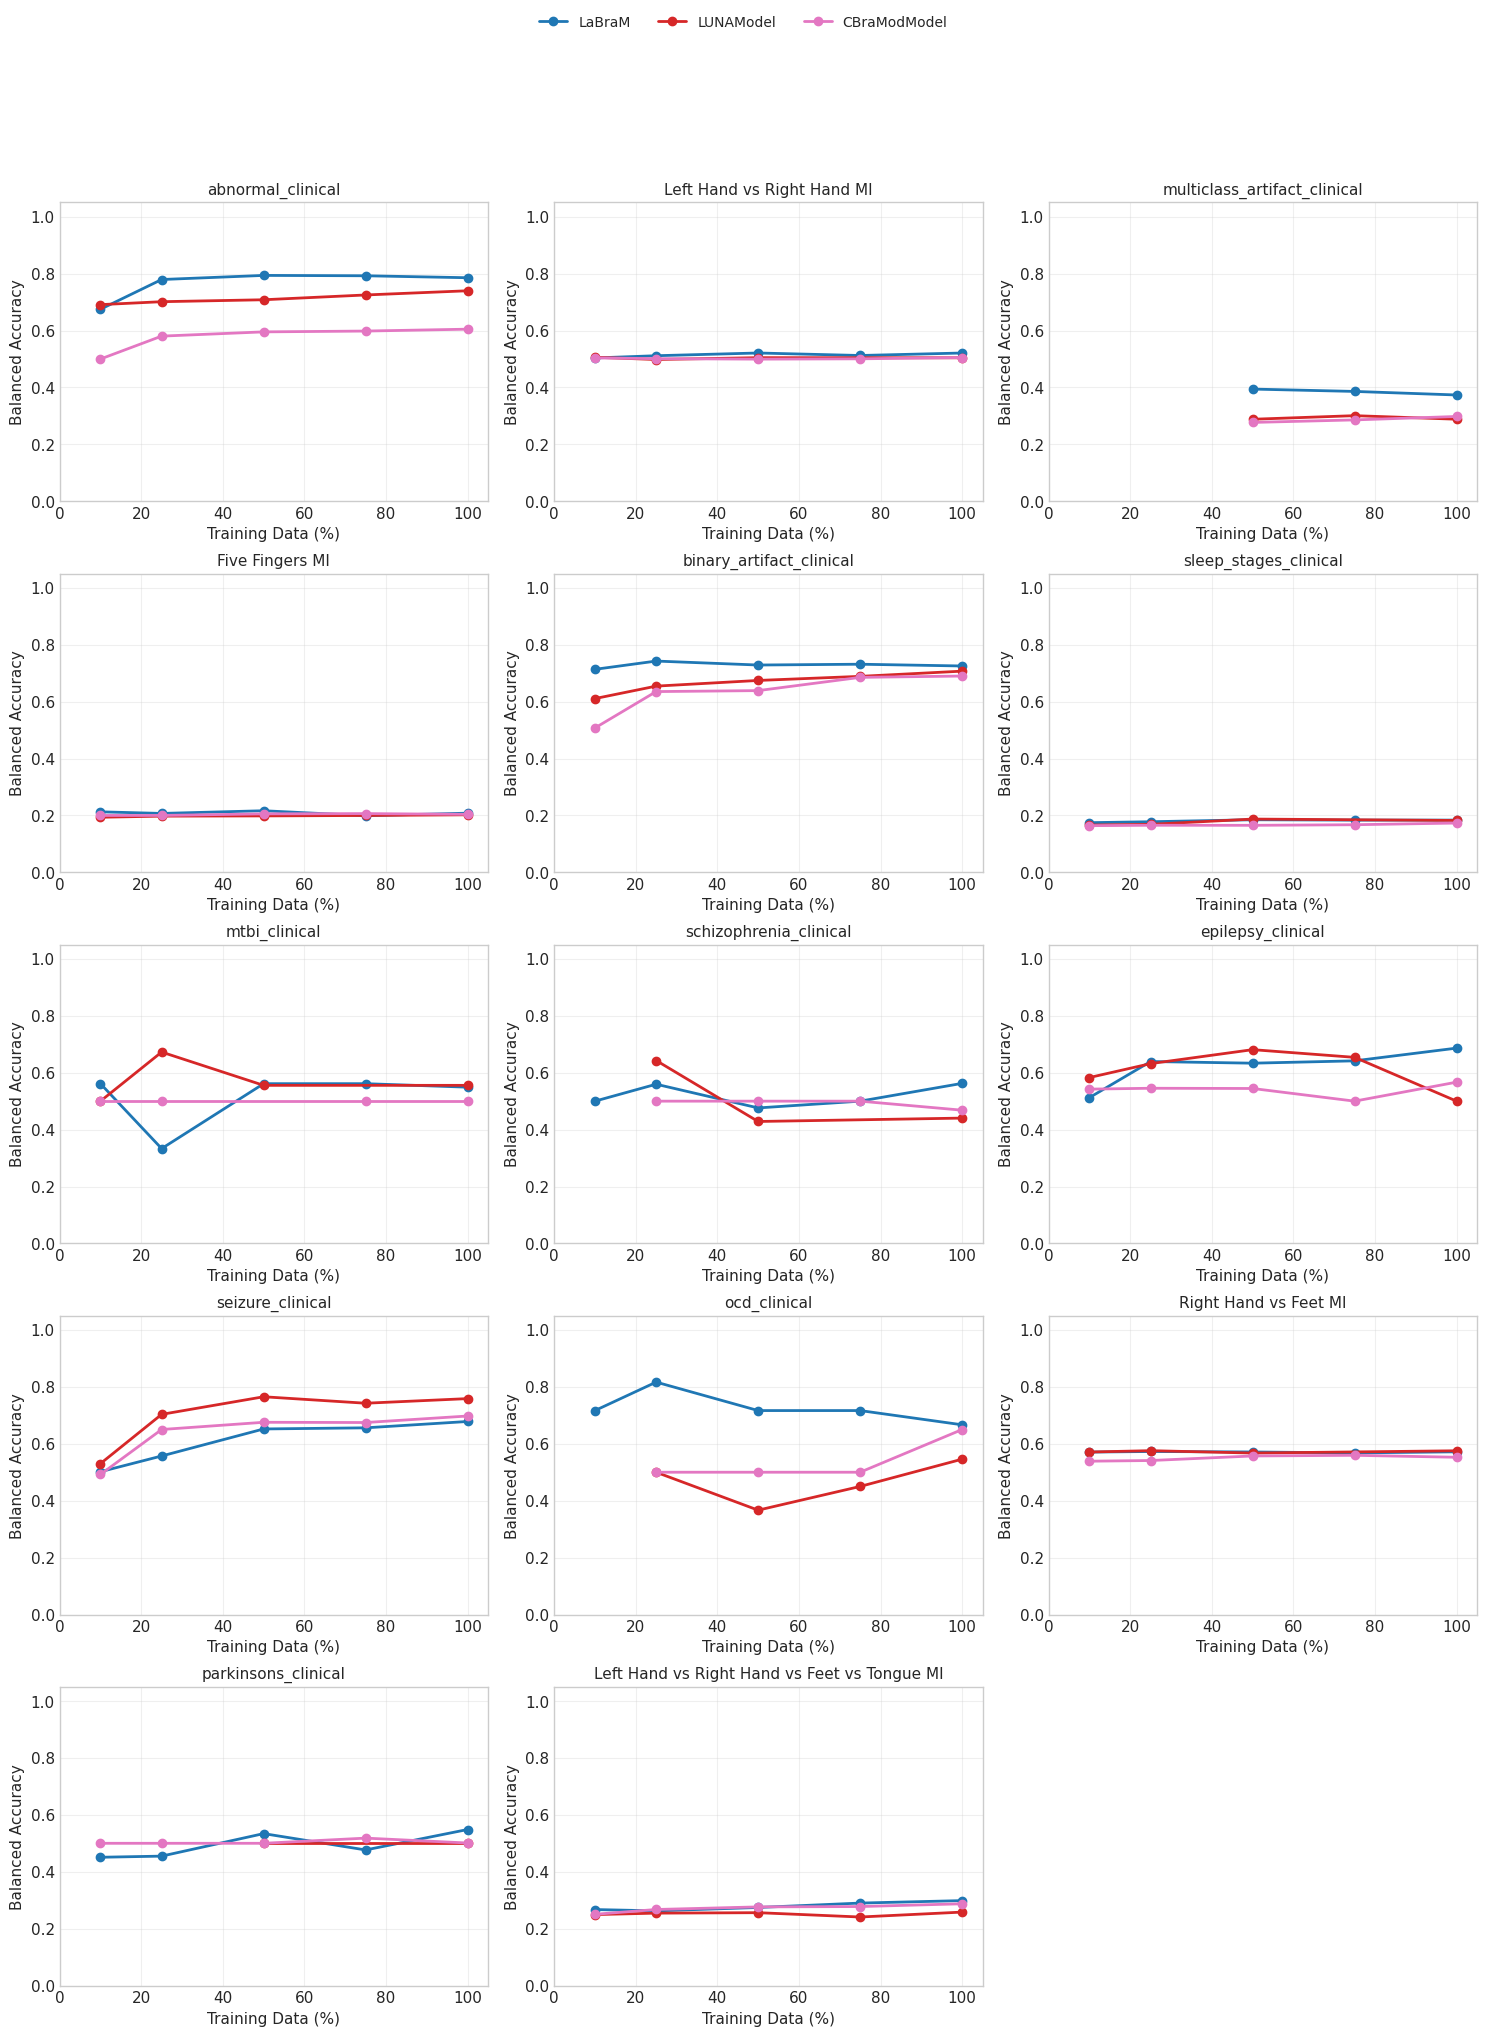

Saved to results/efficiency_curves_grid.png


In [11]:
# Plot grid view
if len(df) > 0 and df["task"].nunique() > 1:
    plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [12]:
def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
    """Create pivot table: models (rows) x tasks (columns)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None
    
    table = subset.pivot_table(
        values=metric,
        index="model_display",
        columns="task_display",
        aggfunc="mean"
    )
    
    # Add mean column
    table["Mean"] = table.mean(axis=1)
    
    # Sort by mean performance
    table = table.sort_values("Mean", ascending=False)
    
    return table.round(3)

In [13]:
# Display comparison table at 100% data
if len(df) > 0:
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        print("Model Comparison (100% training data, Balanced Accuracy):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))

Model Comparison (100% training data, Balanced Accuracy):


task_display,Five Fingers MI,Left Hand vs Right Hand MI,Left Hand vs Right Hand vs Feet vs Tongue MI,Right Hand vs Feet MI,abnormal_clinical,binary_artifact_clinical,epilepsy_clinical,mtbi_clinical,multiclass_artifact_clinical,ocd_clinical,parkinsons_clinical,schizophrenia_clinical,seizure_clinical,sleep_stages_clinical,Mean
model_display,,,,,,,,,,,,,,,
LaBraM,0.208000,0.521000,0.299000,0.572000,0.786000,0.725000,0.686000,0.549000,0.374000,0.667000,0.548000,0.562000,0.678000,0.184000,0.526000
LUNAModel,0.202000,0.504000,0.258000,0.575000,0.740000,0.707000,0.500000,0.556000,0.288000,0.546000,0.500000,0.440000,0.759000,0.182000,0.483000
CBraModModel,0.204000,0.505000,0.287000,0.553000,0.605000,0.690000,0.567000,0.500000,0.298000,0.650000,0.501000,0.468000,0.698000,0.173000,0.478000


In [17]:
def plot_comparison_heatmap(df, percentage=1.0, metric="accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

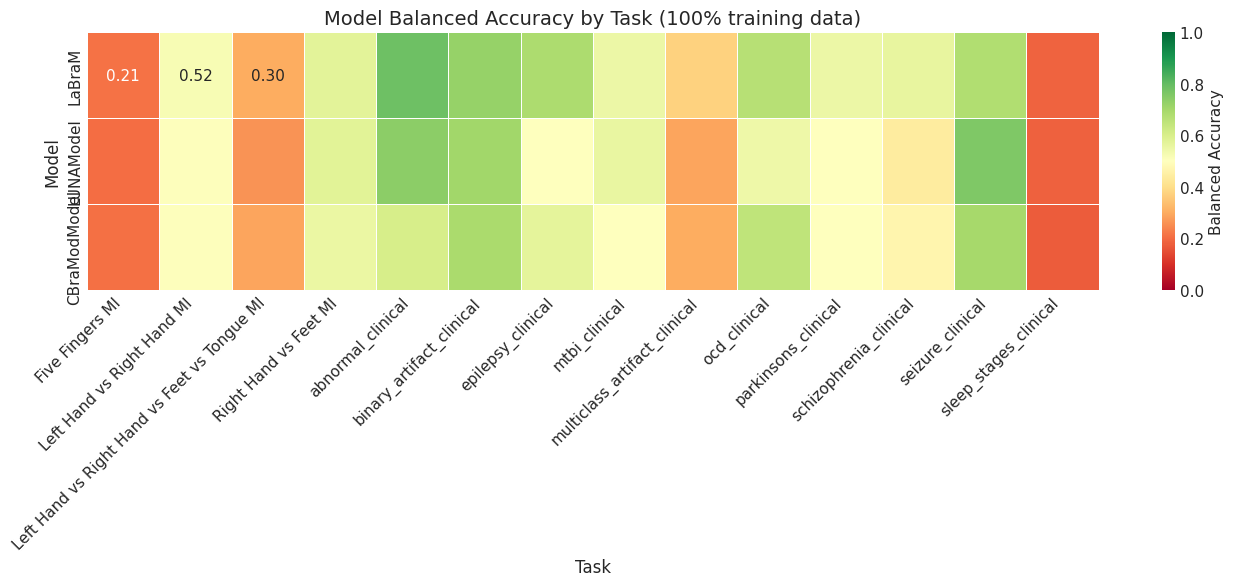

Saved to results/comparison_heatmap_balanced_accuracy.png


In [18]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [19]:
def best_model_per_task(df, percentage=1.0, metric="accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    idx = subset.groupby("task")[metric].idxmax()
    best = subset.loc[idx][["task", "task_display", "model_display", metric]].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [20]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_accuracy
18,Five Fingers MI,Five Fingers MI,CBraModModel,0.228541
192,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LaBraM,0.528126
244,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LaBraM,0.306203
82,Right Hand vs Feet MI,Right Hand vs Feet MI,CBraModModel,0.584334
118,abnormal_clinical,abnormal_clinical,LaBraM,0.800725
193,binary_artifact_clinical,binary_artifact_clinical,LUNAModel,0.748039
105,epilepsy_clinical,epilepsy_clinical,LUNAModel,0.686375
125,mtbi_clinical,mtbi_clinical,LaBraM,0.750000
102,multiclass_artifact_clinical,multiclass_artifact_clinical,LaBraM,0.496492
124,ocd_clinical,ocd_clinical,LaBraM,0.818182


In [21]:
def compute_model_rankings(df, percentage=1.0, metric="accuracy"):
    """Compute average rank of each model across tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [22]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

Model Rankings (lower rank = better)


,Avg Rank,Avg Accuracy
model_display,,
LaBraM,5.80,0.54
CBraModModel,6.49,0.47
LUNAModel,8.73,0.47


## 5. BCI vs Clinical Comparison

In [23]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    
    # Group by model and task type
    comparison = subset.groupby(["model_display", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

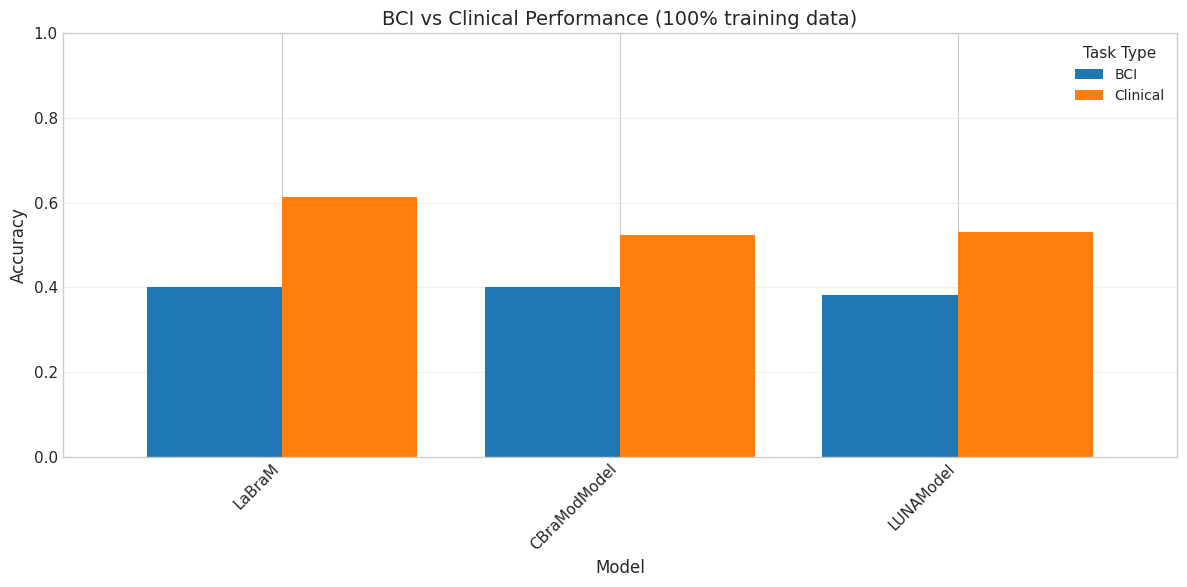

Saved to results/bci_vs_clinical.png


In [24]:
# BCI vs Clinical comparison
if len(df) > 0:
    plot_bci_vs_clinical(df)

## 6. Export Results

In [25]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

In [26]:
# Example: Filter and analyze specific subset
# df_lejepa = df[df["model_display"] == "LeJEPA"]
# df_bci = df[df["task_type"] == "BCI"]
# df_low_data = df[df["percentage"] <= 0.1]

In [27]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)

## 8. Additional Experiments: Noise Robustness

All plots above use clean-only results. This section visualizes the noise sweeps.


In [ ]:
def plot_noise_robustness(df_all, task, metric="balanced_accuracy", percentage=1.0, figsize=(10, 6)):
    """Plot performance vs SNR for noisy evaluation runs."""
    if len(df_all) == 0 or "noise_snr_db" not in df_all.columns or "is_clean" not in df_all.columns:
        print("No noise-aware results available.")
        return

    noisy = df_all[(df_all["task"] == task) & (~df_all["is_clean"])].copy()
    noisy = noisy[noisy["percentage"] == percentage]
    noisy = noisy.dropna(subset=["noise_snr_db"])

    if len(noisy) == 0:
        print(f"No noisy runs found for task={task} at percentage={percentage}.")
        return

    noisy = noisy.sort_values("noise_snr_db", ascending=False)

    clean = df_all[(df_all["task"] == task) & (df_all["is_clean"]) & (df_all["percentage"] == percentage)]
    clean_baseline = clean.groupby("model_display")[metric].mean() if len(clean) > 0 else None

    plt.figure(figsize=figsize)
    grouped = noisy.groupby(["model_display", "noise_types_str", "noise_snr_db"])[metric].mean().reset_index()

    for (model, noise_types), sub in grouped.groupby(["model_display", "noise_types_str"]):
        sub = sub.sort_values("noise_snr_db", ascending=False)
        label = model if not noise_types else f"{model} ({noise_types})"
        plt.plot(sub["noise_snr_db"], sub[metric], marker="o", linewidth=2, label=label)

        if clean_baseline is not None and model in clean_baseline.index:
            plt.axhline(clean_baseline.loc[model], linestyle="--", alpha=0.3)

    plt.xlabel("SNR (dB)")
    plt.ylabel(metric.replace("_", " " ).title())
    plt.title(f"Noise Robustness: {TASK_DISPLAY_NAMES.get(task, task)} ({int(percentage*100)}% train)")
    plt.gca().invert_xaxis()
    plt.ylim(0, 1.05)
    plt.legend(fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()


if len(df_noise) > 0:
    plot_noise_robustness(df_all, task="abnormal_clinical", metric="balanced_accuracy", percentage=1.0)
else:
    print("No noise experiments found yet.")


In [ ]:
for task in sorted(df_all['task'].unique()) if len(df_all) > 0 else []:
    df_for_noiseplot = df_all[(df_all["task"] == task) & (df_all["percentage"] == 1.0)]
    if "is_clean" not in df_for_noiseplot.columns or "noise_snr_db" not in df_for_noiseplot.columns:
        continue

    clean_baseline = df_for_noiseplot[df_for_noiseplot["is_clean"]].groupby("model_display")["balanced_accuracy"].mean()
    noise_to_plot = df_for_noiseplot[~df_for_noiseplot["is_clean"]].sort_values("noise_snr_db", ascending=False)
    if noise_to_plot.empty:
        continue

    noise_to_plot = noise_to_plot.copy()
    noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].replace('gaussian+one_over_f+emg+channel_dropout', 'all')

    plt.figure()
    sns.lineplot(
        data=noise_to_plot[noise_to_plot['noise_types_str'] == 'all'],
        x='noise_snr_db',
        y='balanced_accuracy',
        hue='noise_types_str',
        markers=True,
        dashes=False,
    )
    if len(clean_baseline) > 0:
        plt.axhline(clean_baseline.iloc[0], label='no noise baseline')
    plt.gca().invert_xaxis()
    plt.title(task)
    plt.legend()
    plt.show()


In [ ]:
if len(df_all) > 0:
    df_all.to_csv('results/labram_results_all.csv', index=False)
    print('Exported full clean+noise results to results/labram_results_all.csv')
